# Automation Displacement Score — 830 BLS Occupations

This notebook runs a four-parameter model to score every US occupation in the [BLS SOC 2018](https://www.bls.gov/soc/) system on its risk of displacement by **robots** and **AI**, then lets you explore the results interactively.

## The formula

```
Displacement = (RobotTech × PhysShare + AItech × CogShare) × (1 − Barrier)
```

| Parameter | What it measures | Source |
|-----------|-----------------|--------|
| **RobotTech** | Technical capability of robots for the physical tasks of this job | IFR 2022 industry robot density + O*NET physical task structure |
| **AItech** | LLM capability for the cognitive tasks | Eloundou et al. (2023) β-scores + Anthropic Economic Index (2026) |
| **PhysShare** | What fraction of the job's economic value is physical vs cognitive | O*NET Work Activities elements 4.A.3.* |
| **Barrier** | Social, legal & institutional friction preventing displacement even if technically feasible | max(constitutional bar, licensing+liability, consumer preference via Pew surveys) |

The `max()` rule for Barrier: one absolute barrier (e.g., constitutional requirement for elected officials) is enough to suppress displacement regardless of technical capability.

---
Built on methodology from [Anthropic Labor Market Impacts (2026)](https://www.anthropic.com/research/labor-market-impacts).

In [1]:
# Install dependencies
!pip install pandas numpy matplotlib seaborn -q

zsh:1: command not found: pip


In [2]:
# If running from the repo, import the scoring engine directly
# Otherwise, we'll load the pre-scored CSV

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## Option A — Load pre-scored results (fast)
Use this if you just want to explore the data.

In [3]:
# Load pre-scored CSV (download from GitHub or upload manually)
df = pd.read_csv('bls_automation_scores.csv')
print(f'Loaded {len(df)} occupations')
df.head(10)

Loaded 830 occupations


,soc,title,group,group_name,phys_share,ai_tech,robot_tech,barrier,raw_capability,displacement,primary_threat
0,11-1011,Chief Executives,11,Management,4,52,3,25,50.0,38,AI
1,11-1021,General & Operations Managers,11,Management,4,52,3,25,50.0,38,AI
2,11-1031,Legislators,11,Management,4,52,3,95,50.0,3,AI
3,11-2011,Advertising & Promotions Managers,11,Management,4,52,3,25,50.0,38,AI
4,11-2021,Marketing Managers,11,Management,4,52,3,25,50.0,38,AI
5,11-2022,Sales Managers,11,Management,4,52,3,25,50.0,38,AI
6,11-2031,Public Relations & Fundraising Managers,11,Management,4,52,3,25,50.0,38,AI
7,11-3012,Administrative Services Managers,11,Management,4,52,3,25,50.0,38,AI
8,11-3013,Facilities Managers,11,Management,4,52,3,25,50.0,38,AI
9,11-3021,Computer & Information Systems Managers,11,Management,4,52,3,25,50.0,38,AI


## Option B — Re-run the full scoring pipeline
This re-derives all scores from the algorithm. Takes ~5 seconds.

In [4]:
# Only run this cell if you want to regenerate scores from scratch
# Requires score_engine.py, occupations.py, and run.py in the same directory

import sys, importlib
sys.path.insert(0, '.')

from score_engine import score_occupation
from occupations import ALL_OCCUPATIONS

records = [score_occupation(soc, title, grp) for soc, title, grp in ALL_OCCUPATIONS]
df = pd.DataFrame(records)
print(f'Scored {len(df)} occupations')
df.head()

Scored 830 occupations


,soc,title,group,group_name,phys_share,ai_tech,robot_tech,barrier,raw_capability,displacement,primary_threat
0,11-1011,Chief Executives,11,Management,4,52,3,25,50.0,38,AI
1,11-1021,General & Operations Managers,11,Management,4,52,3,25,50.0,38,AI
2,11-1031,Legislators,11,Management,4,52,3,95,50.0,3,AI
3,11-2011,Advertising & Promotions Managers,11,Management,4,52,3,25,50.0,38,AI
4,11-2021,Marketing Managers,11,Management,4,52,3,25,50.0,38,AI


## 1. Summary statistics

In [5]:
print('=== Displacement Score Distribution ===')
bins = [
    ('Very high (65%+)',  df['displacement'] >= 65),
    ('High (45–65%)',    (df['displacement'] >= 45) & (df['displacement'] < 65)),
    ('Moderate (25–45%)',(df['displacement'] >= 25) & (df['displacement'] < 45)),
    ('Low (10–25%)',     (df['displacement'] >= 10) & (df['displacement'] < 25)),
    ('Resistant (<10%)', df['displacement'] < 10),
]
for label, mask in bins:
    n = mask.sum()
    print(f'  {label:22s}: {n:4d} occupations  ({n/len(df)*100:.1f}%)')

print(f'\nMean displacement: {df.displacement.mean():.1f}%')
print(f'Median displacement: {df.displacement.median():.1f}%')
print(f'\nPrimary threat breakdown:')
print(df.primary_threat.value_counts().to_string())

=== Displacement Score Distribution ===
  Very high (65%+)      :   43 occupations  (5.2%)
  High (45–65%)         :  214 occupations  (25.8%)
  Moderate (25–45%)     :  260 occupations  (31.3%)
  Low (10–25%)          :  233 occupations  (28.1%)
  Resistant (<10%)      :   80 occupations  (9.6%)

Mean displacement: 33.8%
Median displacement: 36.0%

Primary threat breakdown:
primary_threat
AI         460
Robotic    332
Both        38


## 2. Top and bottom occupations

In [6]:
cols = ['soc','title','displacement','primary_threat','ai_tech','robot_tech','phys_share','barrier']

print('=== 20 Most Displaced Occupations ===')
display(df.nlargest(20, 'displacement')[cols])

print('\n=== 20 Most Resistant Occupations ===')
display(df.nsmallest(20, 'displacement')[cols])

=== 20 Most Displaced Occupations ===


,soc,title,displacement,primary_threat,ai_tech,robot_tech,phys_share,barrier
694,51-4122,"Welding, Soldering & Brazing Machine Operators",86,Robotic,5,95,95,5
80,15-1251,Computer Programmers,83,AI,88,3,1,5
81,15-1252,Software Developers,83,AI,88,3,1,5
83,15-1254,Web Developers,83,AI,88,3,1,5
515,43-8011,Data Entry Keyers,80,AI,90,4,7,5
517,43-9021,Data Entry Keyers (NEC),80,AI,90,4,7,5
693,51-4121,"Welders, Cutters & Welder Fitters",79,Robotic,5,87,95,5
749,51-9111,Packaging & Filling Machine Operators,77,Robotic,5,94,85,5
524,43-9081,Proofreaders & Copy Markers,76,AI,86,4,7,5
477,43-3031,"Bookkeeping, Accounting & Auditing Clerks",74,AI,84,4,7,5



=== 20 Most Resistant Occupations ===


,soc,title,displacement,primary_threat,ai_tech,robot_tech,phys_share,barrier
366,31-9011,Massage Therapists,1,AI,5,2,58,68
184,21-2011,Clergy,2,AI,20,2,6,90
445,39-9011,Childcare Workers,2,AI,9,2,55,70
2,11-1031,Legislators,3,AI,52,3,4,95
150,19-3031,Clinical & Counseling Psychologists,3,AI,20,3,18,80
219,25-1111,Criminal Justice & Law Enforcement Teachers,3,AI,38,3,6,92
308,29-1066,Psychiatrists,3,AI,25,13,38,85
817,55-1011,Army Officers,3,Both,21,18,55,85
818,55-1012,Navy Officers,3,Both,21,18,55,85
819,55-1013,Marine Officers,3,Both,21,18,55,85


## 3. Group averages

In [7]:
grp_avg = df.groupby('group_name')['displacement'].agg(['mean','count']).round(1)
grp_avg.columns = ['avg_displacement', 'n_occupations']
grp_avg = grp_avg.sort_values('avg_displacement', ascending=False)
print(grp_avg.to_string())

                                  avg_displacement  n_occupations
group_name                                                       
Computer & Math                               74.4             22
Office & Admin Support                        63.0             55
Production                                    52.1            111
Business & Financial                          48.6             34
Architecture & Eng                            45.6             36
Install/Maint/Repair                          43.6             52
Transportation & Material Moving              39.2             51
Sales                                         37.8             22
Management                                    36.0             36
Farming/Fishing/Forestry                      34.6             14
Life/Physical Science                         32.1             42
Building & Grounds                            30.7              9
Arts & Entertainment                          27.2             38
Food Prepa

## 4. Visualisation — group bar chart

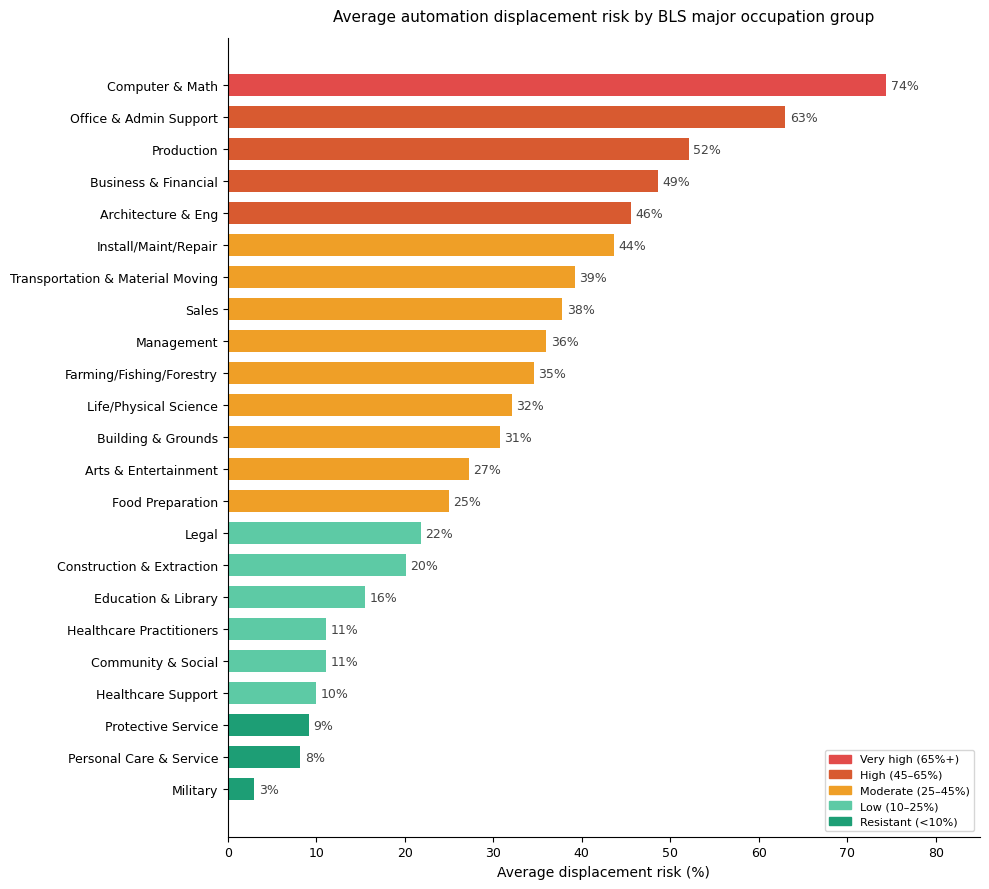

In [8]:
fig, ax = plt.subplots(figsize=(10, 9))

g = grp_avg.sort_values('avg_displacement')

def bar_color(v):
    if v >= 65: return '#E24B4A'
    if v >= 45: return '#D85A30'
    if v >= 25: return '#EF9F27'
    if v >= 10: return '#5DCAA5'
    return '#1D9E75'

colors = [bar_color(v) for v in g['avg_displacement']]
bars = ax.barh(g.index, g['avg_displacement'], color=colors, height=0.7)

for bar, val in zip(bars, g['avg_displacement']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=9, color='#444')

ax.set_xlabel('Average displacement risk (%)', fontsize=10)
ax.set_xlim(0, 85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=9)
ax.set_title('Average automation displacement risk by BLS major occupation group', fontsize=11, pad=12)

patches = [
    mpatches.Patch(color='#E24B4A', label='Very high (65%+)'),
    mpatches.Patch(color='#D85A30', label='High (45–65%)'),
    mpatches.Patch(color='#EF9F27', label='Moderate (25–45%)'),
    mpatches.Patch(color='#5DCAA5', label='Low (10–25%)'),
    mpatches.Patch(color='#1D9E75', label='Resistant (<10%)'),
]
ax.legend(handles=patches, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('group_averages.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Scatter plot — AI tech vs Robot tech

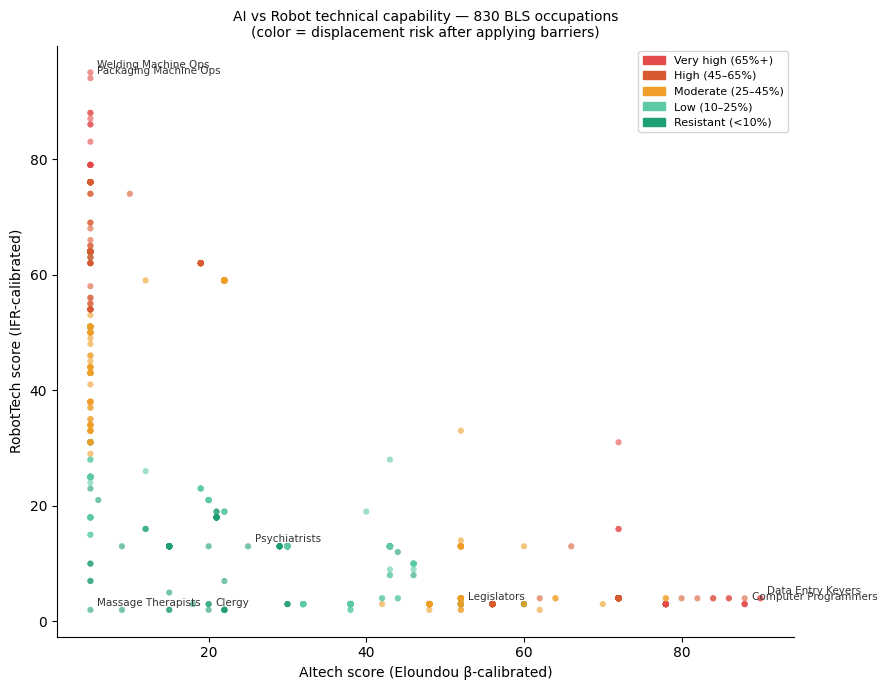

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

colors_scatter = df['displacement'].apply(bar_color)

scatter = ax.scatter(
    df['ai_tech'], df['robot_tech'],
    c=colors_scatter, alpha=0.6, s=20, linewidths=0
)

# Annotate a few key occupations
labels_to_show = {
    '15-1251': 'Computer Programmers',
    '43-8011': 'Data Entry Keyers',
    '51-4122': 'Welding Machine Ops',
    '51-9111': 'Packaging Machine Ops',
    '21-2011': 'Clergy',
    '31-9011': 'Massage Therapists',
    '29-1066': 'Psychiatrists',
    '11-1031': 'Legislators',
}
for soc, label in labels_to_show.items():
    row = df[df['soc']==soc]
    if not row.empty:
        ax.annotate(label, (row['ai_tech'].iloc[0], row['robot_tech'].iloc[0]),
                   fontsize=7.5, xytext=(5,3), textcoords='offset points',
                   color='#333')

ax.set_xlabel('AItech score (Eloundou β-calibrated)', fontsize=10)
ax.set_ylabel('RobotTech score (IFR-calibrated)', fontsize=10)
ax.set_title('AI vs Robot technical capability — 830 BLS occupations\n(color = displacement risk after applying barriers)', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

patches = [
    mpatches.Patch(color='#E24B4A', label='Very high (65%+)'),
    mpatches.Patch(color='#D85A30', label='High (45–65%)'),
    mpatches.Patch(color='#EF9F27', label='Moderate (25–45%)'),
    mpatches.Patch(color='#5DCAA5', label='Low (10–25%)'),
    mpatches.Patch(color='#1D9E75', label='Resistant (<10%)'),
]
ax.legend(handles=patches, fontsize=8)
plt.tight_layout()
plt.savefig('ai_vs_robot.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Search — look up any occupation

In [10]:
# Change search_term to look up any occupation
search_term = 'nurse'

results = df[df['title'].str.lower().str.contains(search_term.lower())]
print(f'Found {len(results)} occupations matching "{search_term}":\n')
display(results[cols].sort_values('displacement', ascending=False))

Found 5 occupations matching "nurse":



,soc,title,displacement,primary_threat,ai_tech,robot_tech,phys_share,barrier
324,29-1171,Nurse Practitioners,14,AI,46,9,18,65
322,29-1151,Nurse Anesthetists,12,AI,46,10,30,65
323,29-1161,Nurse Midwives,12,AI,46,10,30,65
321,29-1141,Registered Nurses,11,AI,43,13,38,65
353,29-2061,Licensed Practical & Vocational Nurses,11,AI,43,13,38,65


## 7. Breakdown for a specific occupation

See the exact arithmetic behind any score.

In [11]:
def breakdown(soc_code):
    row = df[df['soc'] == soc_code]
    if row.empty:
        print(f'SOC {soc_code} not found')
        return
    r = row.iloc[0]
    cog = 100 - r.phys_share
    robot_contrib = round(r.robot_tech * r.phys_share / 100, 1)
    ai_contrib    = round(r.ai_tech    * cog          / 100, 1)
    raw           = round(robot_contrib + ai_contrib, 1)

    print(f"""{'─'*55}
{r['title']} ({r.soc})
Group: {r.group_name}
{'─'*55}
Parameters:
  RobotTech  = {r.robot_tech:3}   (IFR industry density)
  AItech     = {r.ai_tech:3}   (Eloundou β-score calibrated)
  PhysShare  = {r.phys_share:3}%  (O*NET work activities ratio)
  Barrier    = {r.barrier:3}%  (max of legal/social/licensing bars)

Step 1 — Raw capability:
  Robot contribution = {r.robot_tech} × {r.phys_share}/100 = {robot_contrib}
  AI contribution    = {r.ai_tech} × {cog}/100     = {ai_contrib}
  Raw                = {robot_contrib} + {ai_contrib}         = {raw}

Step 2 — Apply barrier:
  Displacement = {raw} × (1 − {r.barrier}/100)
               = {raw} × {round(1-r.barrier/100, 2)}
               = {r.displacement}%

Primary threat: {r.primary_threat}
{'─'*55}""")

# Try different SOC codes
breakdown('43-8011')   # Data Entry Keyers
breakdown('11-1031')   # Legislators
breakdown('51-4122')   # Welding Machine Operators

───────────────────────────────────────────────────────
Data Entry Keyers (43-8011)
Group: Office & Admin Support
───────────────────────────────────────────────────────
Parameters:
  RobotTech  =   4   (IFR industry density)
  AItech     =  90   (Eloundou β-score calibrated)
  PhysShare  =   7%  (O*NET work activities ratio)
  Barrier    =   5%  (max of legal/social/licensing bars)

Step 1 — Raw capability:
  Robot contribution = 4 × 7/100 = 0.3
  AI contribution    = 90 × 93/100     = 83.7
  Raw                = 0.3 + 83.7         = 84.0

Step 2 — Apply barrier:
  Displacement = 84.0 × (1 − 5/100)
               = 84.0 × 0.95
               = 80%

Primary threat: AI
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
Legislators (11-1031)
Group: Management
───────────────────────────────────────────────────────
Parameters:
  RobotTech  =   3   (IFR industry density)
  AItech     =  52   (Eloundou β-score calibrated)
  PhysSh

## 8. Export filtered results

In [12]:
# Export any filtered slice to CSV

# Example: all occupations in the Healthcare Practitioners group
subset = df[df['group_name'] == 'Healthcare Practitioners'].sort_values('displacement', ascending=False)
subset.to_csv('healthcare_displacement.csv', index=False)
print(f'Exported {len(subset)} rows to healthcare_displacement.csv')

# Example: all very high risk occupations
very_high = df[df['displacement'] >= 65].sort_values('displacement', ascending=False)
very_high.to_csv('very_high_risk.csv', index=False)
print(f'Exported {len(very_high)} rows to very_high_risk.csv')

Exported 64 rows to healthcare_displacement.csv
Exported 43 rows to very_high_risk.csv


## 9. Geographic Analysis — State-Level Automation Exposure

Aggregates occupation displacement scores to the state level using May 2024 BLS OEWS employment counts. Each state's `displacement_index` is the employment-weighted mean displacement score across all occupations in that state.

Two files are needed (pre-generated from the pipeline):
- `geo_scores.states.csv` — one row per state with aggregate indices
- `employment_by_region.states.csv` — employment counts per state × occupation

In [13]:
import plotly.express as px
import plotly.graph_objects as go

geo = pd.read_csv('geo_scores.states.csv')
emp_raw = pd.read_csv('employment_by_region.states.csv')
print(f'Loaded {len(geo)} states/territories, {emp_raw.shape[0]:,} employment rows')

geo.sort_values('displacement_index', ascending=False)[
    ['region_id','region_name','displacement_index',
     'ai_raw_index','robot_raw_index','threat_share_ai','threat_share_robotic']
].head(10)

Loaded 53 states/territories, 34,304 employment rows


,region_id,region_name,displacement_index,ai_raw_index,robot_raw_index,threat_share_ai,threat_share_robotic
49,WA,Washington,38.956,33.649,14.285,0.615,0.370
45,UT,Utah,38.789,32.567,14.882,0.599,0.388
50,WI,Wisconsin,38.688,29.093,18.287,0.556,0.432
22,MI,Michigan,38.508,29.703,17.441,0.572,0.417
43,TN,Tennessee,38.378,29.209,17.809,0.562,0.428
46,VA,Virginia,38.303,34.244,13.557,0.636,0.350
30,NH,New Hampshire,38.273,32.005,14.893,0.614,0.371
9,GA,Georgia,38.224,31.609,15.992,0.601,0.389
23,MN,Minnesota,38.113,31.906,15.284,0.607,0.379
39,PR,Puerto Rico,38.084,31.320,15.207,0.626,0.367


### 9a. Interactive choropleth map

Use the dropdown to switch between metrics.

In [14]:
metrics = [
    ('displacement_index',        'Displacement Index (%)',          [34, 41]),
    ('ai_raw_index',              'AI Raw Capability Index',          [27, 34]),
    ('robot_raw_index',           'Robot Raw Capability Index',       [12, 21]),
    ('threat_share_ai_pct',       'AI-Primary Workers (%)',           [50, 70]),
    ('threat_share_robotic_pct',  'Robot-Primary Workers (%)',        [30, 50]),
]

geo_plot = geo.copy()
geo_plot['threat_share_ai_pct']      = (geo_plot['threat_share_ai']      * 100).round(1)
geo_plot['threat_share_robotic_pct'] = (geo_plot['threat_share_robotic'] * 100).round(1)

hover_cols = ['displacement_index', 'ai_raw_index', 'robot_raw_index',
              'threat_share_ai_pct', 'threat_share_robotic_pct']

fig_map = go.Figure()
for i, (col, label, zrng) in enumerate(metrics):
    fig_map.add_trace(go.Choropleth(
        locations=geo_plot['region_id'],
        locationmode='USA-states',
        z=geo_plot[col],
        colorscale='RdYlGn_r',
        zmin=zrng[0], zmax=zrng[1],
        text=geo_plot['region_name'],
        customdata=geo_plot[hover_cols].values,
        hovertemplate=(
            '<b>%{text}</b><br>'
            'Displacement Index: %{customdata[0]:.2f}%<br>'
            'AI Raw: %{customdata[1]:.1f}  |  Robot Raw: %{customdata[2]:.1f}<br>'
            'AI-primary: %{customdata[3]:.1f}%  |  Robot-primary: %{customdata[4]:.1f}%'
            '<extra></extra>'
        ),
        colorbar=dict(title=label, len=0.7),
        visible=(i == 0),
    ))

buttons_map = []
for i, (col, label, _) in enumerate(metrics):
    vis = [j == i for j in range(len(metrics))]
    buttons_map.append(dict(
        label=label, method='update',
        args=[{'visible': vis}, {'title': f'{label} by State (May 2024 OEWS)'}]
    ))

fig_map.update_layout(
    title_text='Automation Displacement Index by State (May 2024 OEWS)',
    geo_scope='usa',
    height=530,
    margin=dict(t=80, b=10),
    updatemenus=[dict(
        active=0, buttons=buttons_map,
        direction='down',
        x=0.01, y=1.02, xanchor='left', yanchor='top',
        bgcolor='#f0f0f0', bordercolor='#ccc',
    )],
)
fig_map.show()

## 10. Top Displaced Jobs by State

For each state, ranks the 20 occupations with the most **workers at risk**:

```
Workers at Risk = Employment in State × Displacement Score / 100
```

Use the dropdown to select a state. Bar color indicates the primary automation threat: <span style='color:#E24B4A'>**red = AI**</span>, <span style='color:#2196F3'>**blue = Robotic**</span>, <span style='color:#9C27B0'>**purple = Both**</span>.

In [15]:
emp_scores = emp_raw.merge(
    df[['soc','title','group_name','displacement','primary_threat']],
    on='soc', how='left'
).dropna(subset=['displacement'])

emp_scores['displacement'] = emp_scores['displacement'].astype(int)
emp_scores['workers_at_risk'] = (
    emp_scores['employment'] * emp_scores['displacement'] / 100
).round(0)

state_list  = sorted(geo['region_id'].unique())
state_names = dict(zip(geo['region_id'], geo['region_name']))
THREAT_COLOR = {'AI': '#E24B4A', 'Robotic': '#2196F3', 'Both': '#9C27B0'}

state_tops = {
    s: emp_scores[emp_scores['region_id'] == s].nlargest(20, 'workers_at_risk')
    for s in state_list
}

fig_state = go.Figure()
for i, state in enumerate(state_list):
    sub = state_tops[state]
    colors = [THREAT_COLOR.get(t, '#888') for t in sub['primary_threat']]
    fig_state.add_trace(go.Bar(
        x=sub['workers_at_risk'],
        y=sub['title'],
        orientation='h',
        marker_color=colors,
        text=[f"{d}%" for d in sub['displacement']],
        textposition='outside',
        customdata=sub[['displacement','group_name','primary_threat','employment']].values,
        hovertemplate=(
            '<b>%{y}</b><br>'
            'Workers at risk: %{x:,.0f}<br>'
            'Displacement: %{customdata[0]}%  |  Group: %{customdata[1]}<br>'
            'Primary threat: %{customdata[2]}<br>'
            'Total employed in state: %{customdata[3]:,.0f}'
            '<extra></extra>'
        ),
        visible=(i == 0),
        showlegend=False,
    ))

buttons_state = []
for i, state in enumerate(state_list):
    vis  = [j == i for j in range(len(state_list))]
    name = state_names.get(state, state)
    buttons_state.append(dict(
        label=f"{state} — {name}",
        method='update',
        args=[{'visible': vis},
              {'title': f'Top 20 Most-Displaced Jobs — {name} (workers at risk)'}]
    ))

first_name = state_names.get(state_list[0], state_list[0])
fig_state.update_layout(
    title=f'Top 20 Most-Displaced Jobs — {first_name} (workers at risk)',
    xaxis_title='Estimated Workers at Risk  (employment × displacement %)',
    yaxis=dict(autorange='reversed', tickfont=dict(size=10)),
    height=650,
    margin=dict(l=300, r=160, t=130, b=60),
    updatemenus=[dict(
        active=0, buttons=buttons_state,
        direction='down',
        x=0.01, y=1.22, xanchor='left', yanchor='top',
        bgcolor='#f0f0f0', bordercolor='#ccc',
    )],
    annotations=[dict(
        x=0.82, y=1.13, xref='paper', yref='paper', showarrow=False,
        text=('<span style="color:#E24B4A">&#9632;</span> AI primary&nbsp;&nbsp;'
              '<span style="color:#2196F3">&#9632;</span> Robotic primary&nbsp;&nbsp;'
              '<span style="color:#9C27B0">&#9632;</span> Both'),
        font=dict(size=11),
    )],
)
fig_state.show()

## 11. National Jobs Most at Risk

Sums workers at risk across all states to find the occupations with the largest national displacement footprint — the jobs where automation threatens the most total workers.

In [16]:
nat = (
    emp_scores
    .groupby(['soc','title','group_name','displacement','primary_threat'], as_index=False)
    .agg(total_employment=('employment','sum'), workers_at_risk=('workers_at_risk','sum'))
    .sort_values('workers_at_risk', ascending=False)
    .head(30)
)

colors_nat = [THREAT_COLOR.get(t, '#888') for t in nat['primary_threat']]

fig_nat = go.Figure(go.Bar(
    x=nat['workers_at_risk'],
    y=nat['title'],
    orientation='h',
    marker_color=colors_nat,
    text=[f"{d}%" for d in nat['displacement'].astype(int)],
    textposition='outside',
    customdata=nat[['displacement','group_name','primary_threat','total_employment']].values,
    hovertemplate=(
        '<b>%{y}</b><br>'
        'National workers at risk: %{x:,.0f}<br>'
        'Displacement score: %{customdata[0]}%<br>'
        'Group: %{customdata[1]}  |  Threat: %{customdata[2]}<br>'
        'Total nationally employed: %{customdata[3]:,.0f}'
        '<extra></extra>'
    ),
))

fig_nat.update_layout(
    title='Top 30 Occupations by National Workers at Risk',
    xaxis_title='Estimated National Workers at Risk  (employment × displacement %)',
    yaxis=dict(autorange='reversed', tickfont=dict(size=10)),
    height=780,
    margin=dict(l=320, r=160, t=70, b=60),
    annotations=[dict(
        x=0.82, y=1.04, xref='paper', yref='paper', showarrow=False,
        text=('<span style="color:#E24B4A">&#9632;</span> AI primary&nbsp;&nbsp;'
              '<span style="color:#2196F3">&#9632;</span> Robotic primary&nbsp;&nbsp;'
              '<span style="color:#9C27B0">&#9632;</span> Both'),
        font=dict(size=11),
    )],
)
fig_nat.show()

## Going fully empirical

The current pipeline uses group-level baselines derived from published summaries of O*NET, IFR, and Eloundou data. To replace these with live queries:

### O*NET PhysShare (free API, requires registration at [onetcenter.org](https://services.onetcenter.org/developer/home))

```python
import requests

def get_phys_share(soc_code, api_key):
    url = f'https://services.onetcenter.org/ws/online/occupations/{soc_code}/details/work_activities'
    r = requests.get(url, headers={'Authorization': f'Basic {api_key}'})
    data = r.json()
    
    physical_ids = ['4.A.3.a.1','4.A.3.a.2','4.A.3.a.3','4.A.3.a.4',
                    '4.A.3.b.1','4.A.3.b.2','4.A.3.b.3','4.A.3.b.4']
    
    elements = data.get('element', [])
    phys = sum(e['score']['value'] for e in elements if e['id'] in physical_ids)
    total = sum(e['score']['value'] for e in elements)
    return phys / total if total > 0 else 0.1
```

### Eloundou β scores (public data)

Download `gptsRgpts_occ_lvl.csv` from:
```
https://github.com/EIG-Research/AI-unemployment/blob/main/data/gptsRgpts_occ_lvl.csv
```
Then merge on SOC code to get published β averages.

### IFR robot density

Available via IFR annual subscription. Use the industry density table in `score_engine.py` as a free approximation (derived from published IFR summaries).

---

## References

- Eloundou et al. (2023). GPTs are GPTs. *Science*, 384, 1306–1308. https://arxiv.org/abs/2303.10130
- Massenkoff & McCrory (2026). Labor market impacts of AI. Anthropic Economic Index. https://www.anthropic.com/research/labor-market-impacts
- Acemoglu & Restrepo (2020). Robots and Jobs. *Journal of Political Economy*.
- IFR (2022). World Robotics Report. https://ifr.org
- Pew Research Center (2014). AI, Robotics, and the Future of Jobs.